In [2]:
import numpy as np
import pandas as pd

# Task 0
Read the dataset from csv file & perform data cleaning - remove all rows, which contains `?` in some columns.
Also check for data correctness (salary & salary $K).

In [17]:
# write your code for task 0 here
data = pd.read_csv('../data/adult.csv')
data = data.replace('?', np.nan)
data = data.replace(' ?', np.nan)
data = data.dropna()
data = data.reset_index(drop=True)
data

,Unnamed: 0,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$
0,0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,39
1,1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,35
2,2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,27
3,3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,43
4,4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,32556,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,38,United-States,<=50K,36
30158,32557,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,United-States,>50K,173
30159,32558,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,40,United-States,<=50K,40
30160,32559,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,20,United-States,<=50K,38


# Task 1
Print the count of men and women in the dataset.

In [7]:
count_of_all = len(data)
count_of_men = len(data[data["sex"]=="Male"])
count_of_women = count_of_all - count_of_men

print("Male: ", count_of_men)
print("Female: ", count_of_women)

Male:  21790
Female:  10771


# Task 2
Find the average age of men in dataset

In [8]:
np.mean(data[data["sex"]=="Male"]["age"])

np.float64(39.43354749885268)

# Task 3
Get the percentage of people from Poland (native-country)

In [9]:
poland_total_value = len(data[data["native-country"]=="Poland"])
print("Poland total: ", poland_total_value)
print("Total records: ", len(data['native-country']))
print("Poland percent: ", (poland_total_value / len(data['native-country'])) * 100)

Poland total:  60
Total records:  32561
Poland percent:  0.18426952489174164


# Task 4
Get the mean and standard deviation of the age for people who earn > 50K per year. After this, get it for those who earn <= 50K.

In [11]:
age_over_50k = data[data["salary"] == ">50K"]["age"]

mean_over_50k_pd = age_over_50k.mean()
deviation_over_50k_pd = age_over_50k.std() 
mean = np.mean(data[data["salary"] == ">50K"]["age"])
deviation = np.std(data[data["salary"] == ">50K"]["age"])

print(f"Mean age of those who earn >50K: {mean_over_50k_pd:.2f}")
print(f"Standard deviation of age of those who earn >50K: {deviation_over_50k_pd:.2f}")

age_under_50k = data[data["salary"] == "<=50K"]["age"]

mean_under_50k_np = np.mean(age_under_50k)
deviation_under_50k_np = np.std(age_under_50k)

print(f"Mean age of those who earn <=50K: {mean_under_50k_np:.2f}")
print(f"Standard deviation of age of those who earn <=50K: {deviation_under_50k_np:.2f}")


Mean age of those who earn >50K: 44.25
Standard deviation of age of those who earn >50K: 10.52
Mean age of those who earn <=50K: 36.78
Standard deviation of age of those who earn <=50K: 14.02


# Task 5
Check, if there are some people without higher education (education: Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters, Doctorate), but with > 50K salary

In [12]:
higher_education_levels = [
    'Bachelors',
    'Prof-school',
    'Assoc-acdm',
    'Assoc-voc',
    'Masters',
    'Doctorate'
]

over_50k_df = data[data['salary'].str.strip() == '>50K']
people_without_higher_edu_over_50k = over_50k_df[
    ~over_50k_df['education'].str.strip().isin(higher_education_levels) 
]

print(f"Total count of people without higher education found: {len(people_without_higher_edu_over_50k)}")

Total count of people without higher education found: 3306


# Task 6
Get the statistics of age for each type of education. Use `groupby` and `describe` for this.

In [13]:
age_statistics_by_education = data.groupby('education')['age'].describe()
print("Statistics of age for each type of education:")
print(age_statistics_by_education)

Statistics of age for each type of education:
                count       mean        std   min    25%   50%   75%   max
education                                                                 
10th            933.0  37.429796  16.720713  17.0  22.00  34.0  52.0  90.0
11th           1175.0  32.355745  15.545485  17.0  18.00  28.0  43.0  90.0
12th            433.0  32.000000  14.334625  17.0  19.00  28.0  41.0  79.0
1st-4th         168.0  46.142857  15.615625  19.0  33.00  46.0  57.0  90.0
5th-6th         333.0  42.885886  15.557285  17.0  29.00  42.0  54.0  84.0
7th-8th         646.0  48.445820  16.092350  17.0  34.25  50.0  61.0  90.0
9th             514.0  41.060311  15.946862  17.0  28.00  39.0  54.0  90.0
Assoc-acdm     1067.0  37.381443  11.095177  19.0  29.00  36.0  44.0  90.0
Assoc-voc      1382.0  38.553546  11.631300  19.0  30.00  37.0  46.0  84.0
Bachelors      5355.0  38.904949  11.912210  19.0  29.00  37.0  46.0  90.0
Doctorate       413.0  47.702179  11.784716  24.0  39.

# Task 7
Compare the married and non-married men salaries. Who earns more? (>50K or <=50K)
Married men are those, whom `marital-status` starts with "Married". Others are not.

In [14]:
men_df = data[data['sex'] == 'Male']

married_men = men_df[men_df['marital-status'].str.startswith('Married')]
non_married_men = men_df[~men_df['marital-status'].str.startswith('Married')]

married_men_prop = (married_men['salary'] == '>50K').mean() * 100
non_married_men_prop = (non_married_men['salary'] == '>50K').mean() * 100

print(f"Proportion of married men earning >50K: {married_men_prop:.2f}%")
print(f"Proportion of non-married men earning >50K: {non_married_men_prop:.2f}%")

Proportion of married men earning >50K: 44.05%
Proportion of non-married men earning >50K: 8.45%


# Task 8
Get the max hours per week some person works. How many people works the same amount of hours per week?

In [15]:
max_hours = data["hours-per-week"].max()
busiest_people = data[data["hours-per-week"] == max_hours]
busiest_people
len(busiest_people)

85

# Task 9
Analyze the correlation between data in dataset. Understand connected fields in it and print highlight thier connection.

Correlation Matrix (Numeric Features):
                 Unnamed: 0       age  hours-per-week  salary K$
Unnamed: 0        1.000000  0.001286        0.000607  -0.001666
age               0.001286  1.000000        0.068756   0.201774
hours-per-week    0.000607  0.068756        1.000000   0.196916
salary K$        -0.001666  0.201774        0.196916   1.000000


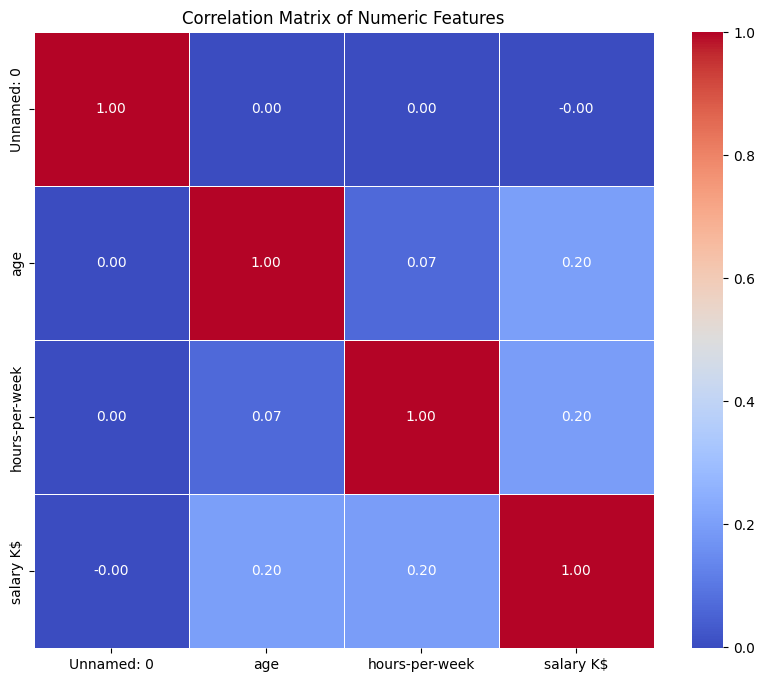

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_data = data.select_dtypes(include=[np.number])

correlation_matrix = numeric_data.corr(method='pearson')

print("Correlation Matrix (Numeric Features):\n", correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()
